# 🏭 Week 1: Data Ingestion & Exploratory Analysis
**Project:** Infotact Contextual Predictive Maintenance (IoT Edge AI)  
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Branch:** ram-dev  
**Date:** June 2026  

## Objectives
- Load and validate the AI4I 2020 dataset
- Analyze failure type distributions
- Explore sensor feature distributions
- Identify correlations between features and failures
- Engineer signal processing features for ML pipeline

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All libraries imported successfully!")

All libraries imported successfully!


## 📥 1. Data Loading & Validation
Loading the AI4I 2020 dataset and performing basic validation checks including shape, dtypes, null values, and class distribution.

## 1. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv('../data/ai4i2020.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (10000, 14)


In [ ]:
## 2. First Look at the Data

In [4]:
# Display first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Display last 5 rows
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [5]:
# Check dataset info - column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [6]:
# Check basic statistics of all numerical columns
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
# Check for missing values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
# Check for duplicate rows
print(f"Total duplicate rows: {df.duplicated().sum()}")

Total duplicate rows: 0


class distribution
Count of Failures and non failures and their percentage

In [9]:
# Check class distribution of target variable
print("Machine Failure Distribution:")
print(df['Machine failure'].value_counts())
print()
print(f"Failure Rate: {df['Machine failure'].mean() * 100:.2f}%")

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Rate: 3.39%


Visulaize

C:\Users\Admin\AppData\Local\Temp\ipykernel_14504\2053889574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, palette='Set2')


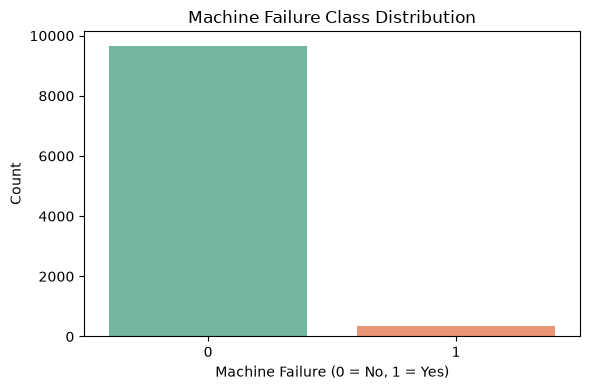

In [10]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df, palette='Set2')
plt.title('Machine Failure Class Distribution')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Check individual failure type distribution

In [11]:
# Check individual failure type distribution
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("Individual Failure Type Counts:")
for col in failure_cols:
    count = df[col].sum()
    print(f"  {col}: {count} failures")

Individual Failure Type Counts:
  TWF: 46 failures
  HDF: 115 failures
  PWF: 95 failures
  OSF: 98 failures
  RNF: 19 failures


C:\Users\Admin\AppData\Local\Temp\ipykernel_14504\3356556620.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Set2')


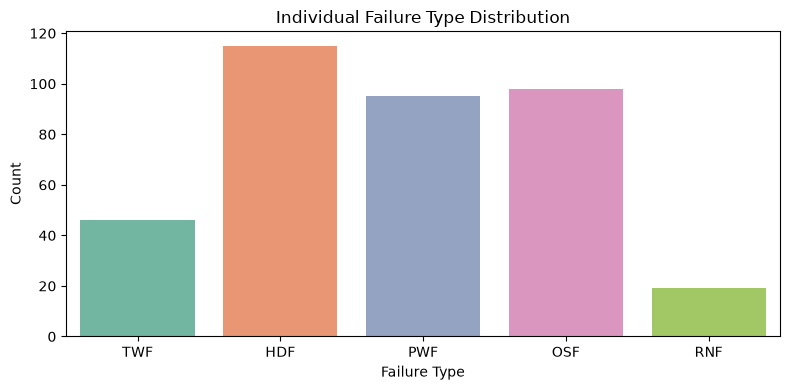

In [12]:
# Visualize individual failure types
failure_counts = df[failure_cols].sum()

plt.figure(figsize=(8, 4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Set2')
plt.title('Individual Failure Type Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14504\1811106425.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Set2')


Chart saved to images folder!


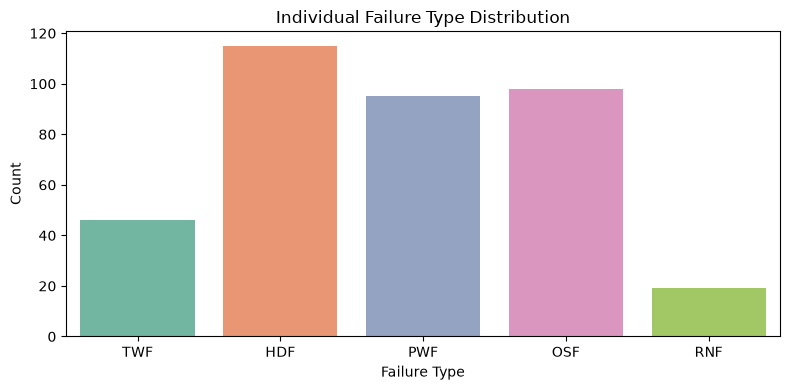

In [15]:
# Save the chart to images folder
failure_counts = df[failure_cols].sum()

plt.figure(figsize=(8, 4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Set2')
plt.title('Individual Failure Type Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/failure_type_distribution.png', dpi=150)
print("Chart saved to images folder!")

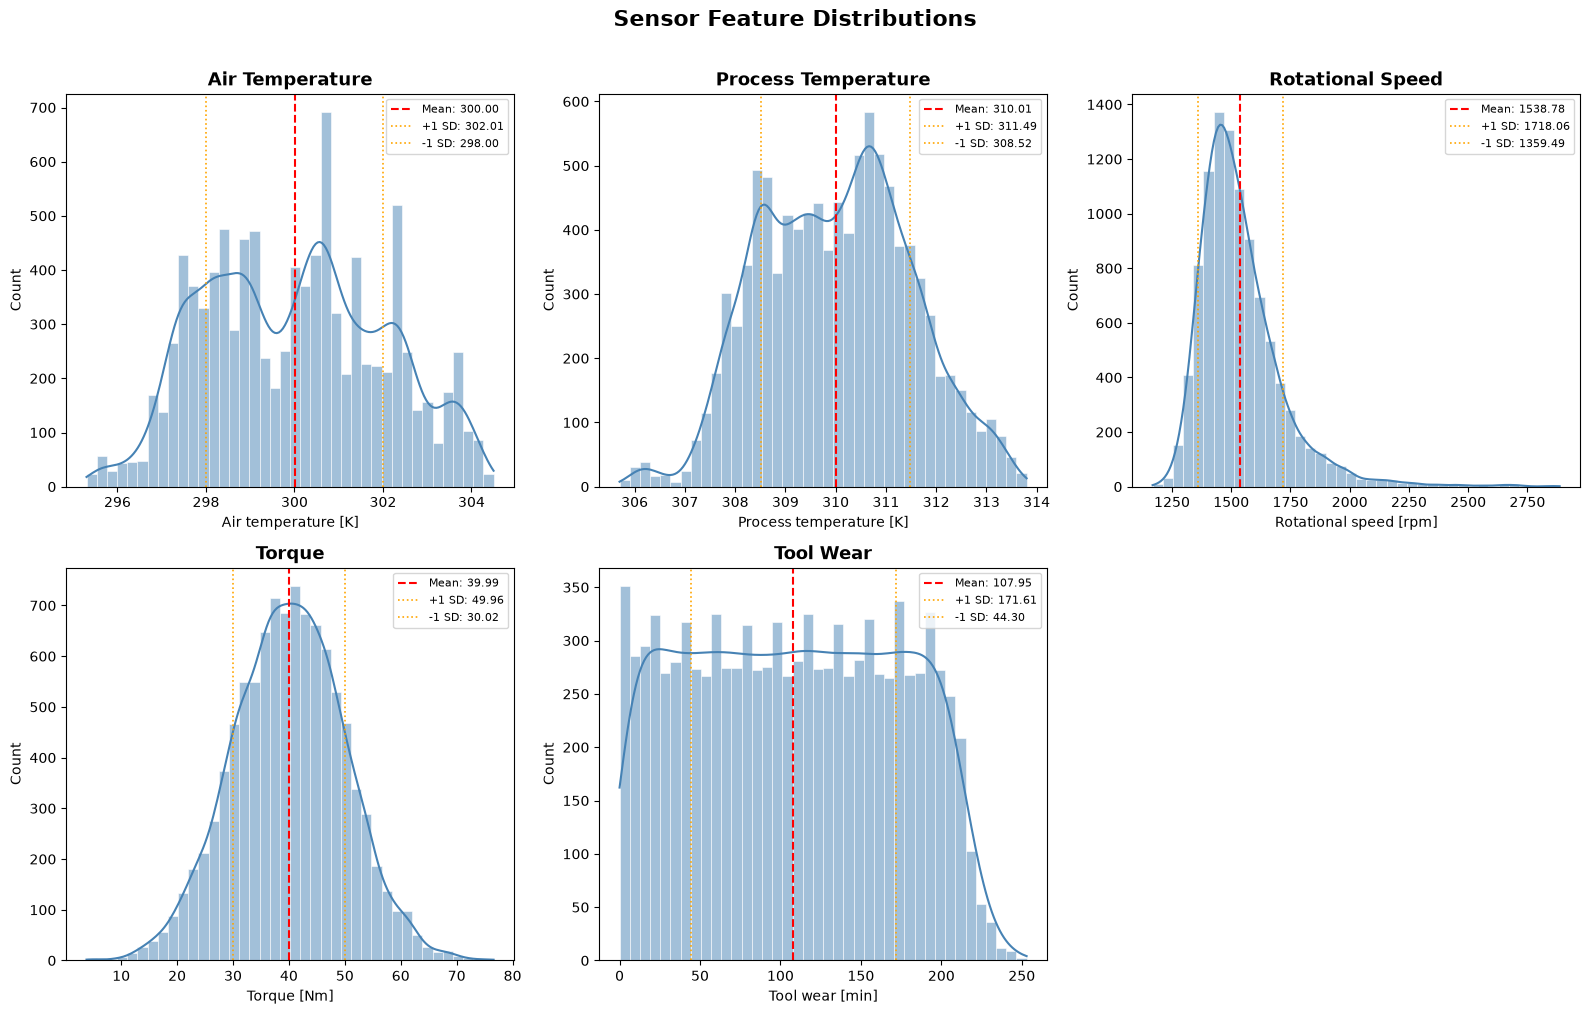

Chart saved to images folder!


In [13]:
# ─── Sensor Distribution Plots ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sensor columns to plot
sensors = {
    'Air temperature [K]': 'Air Temperature',
    'Process temperature [K]': 'Process Temperature',
    'Rotational speed [rpm]': 'Rotational Speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool Wear'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (col, title) in enumerate(sensors.items()):
    ax = axes[idx]
    
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=40, edgecolor='white', linewidth=0.4)
    
    # Mean & std lines
    mean_val = df[col].mean()
    std_val  = df[col].std()
    ax.axvline(mean_val, color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.2, label=f'+1 SD: {mean_val+std_val:.2f}')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.2, label=f'-1 SD: {mean_val-std_val:.2f}')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Sensor Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

# Save
os.makedirs('images', exist_ok=True)
plt.savefig('images/sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images folder!")

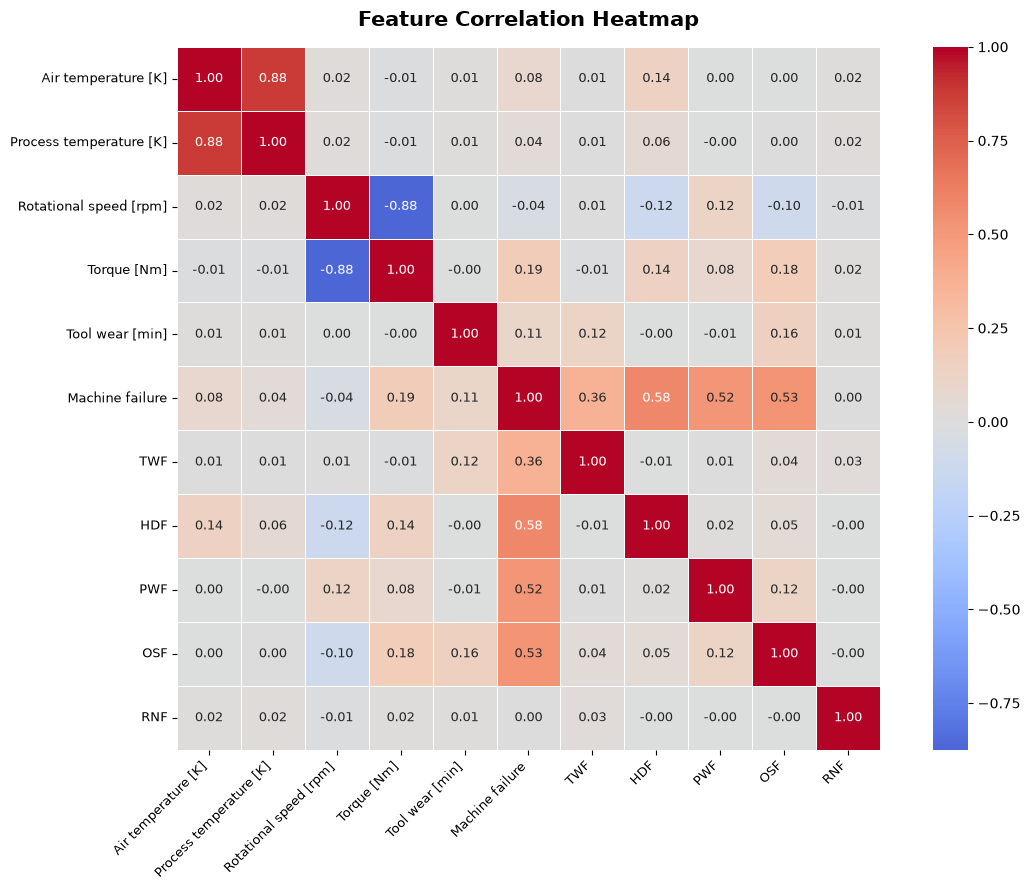

Heatmap saved to images folder!


In [14]:
# ─── Correlation Heatmap ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Select numeric sensor + target columns
corr_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# Save
os.makedirs('images', exist_ok=True)
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to images folder!")

In [17]:
# ─── Signal Processing Features ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# ── 1. Rolling Statistics (window = 10) ──────────────────────────────────────
window = 10

for col in sensor_cols:
    short = col.split(' [')[0].replace(' ', '_')
    df[f'{short}_rolling_mean'] = df[col].rolling(window=window, min_periods=1).mean()
    df[f'{short}_rolling_std']  = df[col].rolling(window=window, min_periods=1).std().fillna(0)

# ── 2. Rate of Change (difference between consecutive rows) ──────────────────
for col in sensor_cols:
    short = col.split(' [')[0].replace(' ', '_')
    df[f'{short}_roc'] = df[col].diff().fillna(0)

# ── 3. Torque × Speed Interaction (power proxy) ──────────────────────────────
df['power_proxy'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# ── 4. Temperature Delta ──────────────────────────────────────────────────────
df['temp_delta'] = df['Process temperature [K]'] - df['Air temperature [K]']

print("✅ New features created:")
new_cols = [c for c in df.columns if any(x in c for x in ['rolling', '_roc', 'power_proxy', 'temp_delta'])]
for c in new_cols:
    print(f"   {c}")
print(f"\nDataset shape: {df.shape}")

✅ New features created:
   Air_temperature_rolling_mean
   Air_temperature_rolling_std
   Process_temperature_rolling_mean
   Process_temperature_rolling_std
   Rotational_speed_rolling_mean
   Rotational_speed_rolling_std
   Torque_rolling_mean
   Torque_rolling_std
   Tool_wear_rolling_mean
   Tool_wear_rolling_std
   Air_temperature_roc
   Process_temperature_roc
   Rotational_speed_roc
   Torque_roc
   Tool_wear_roc
   power_proxy
   temp_delta

Dataset shape: (10000, 31)


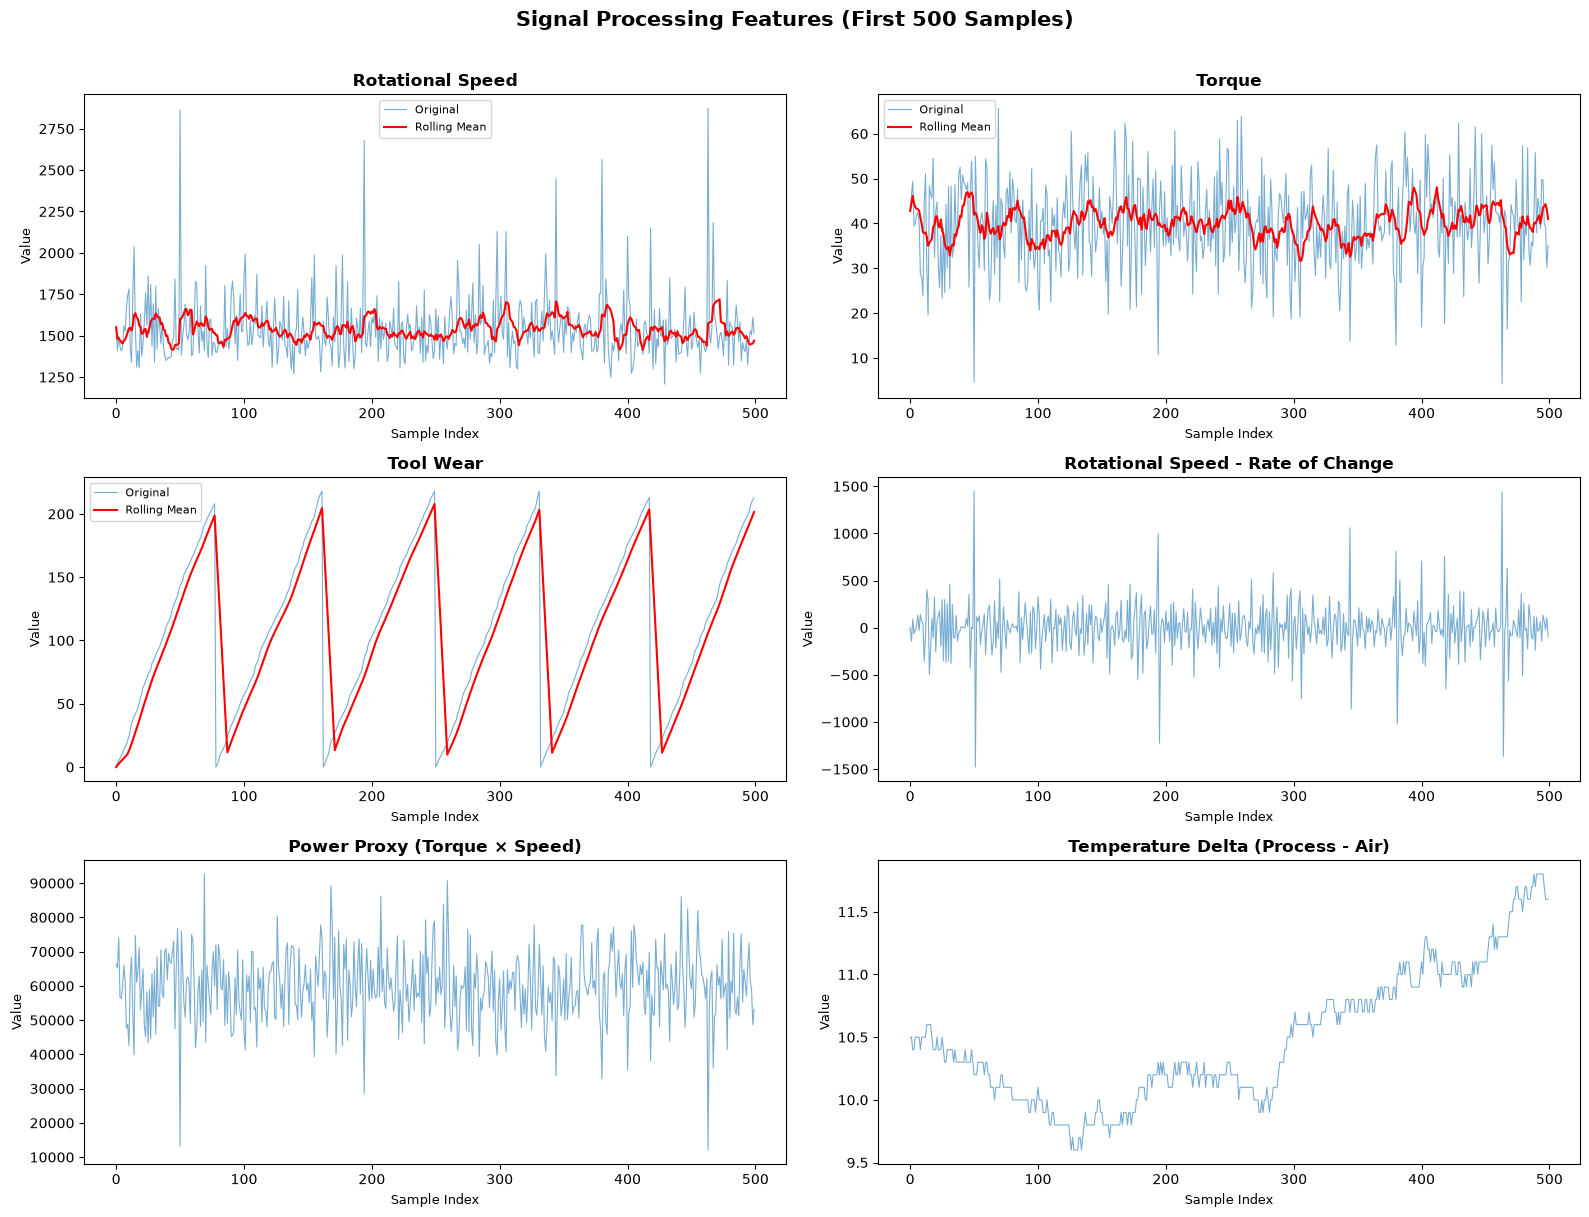

Chart saved to images folder!


In [18]:
# ─── Visualize Signal Processing Features ────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# Plot rolling mean vs original for each sensor
plot_pairs = [
    ('Rotational speed [rpm]', 'Rotational_speed_rolling_mean', 'Rotational Speed'),
    ('Torque [Nm]',            'Torque_rolling_mean',            'Torque'),
    ('Tool wear [min]',        'Tool_wear_rolling_mean',         'Tool Wear'),
    ('Rotational_speed_roc',   None,                             'Rotational Speed - Rate of Change'),
    ('power_proxy',            None,                             'Power Proxy (Torque × Speed)'),
    ('temp_delta',             None,                             'Temperature Delta (Process - Air)'),
]

for idx, (col1, col2, title) in enumerate(plot_pairs):
    ax = axes[idx]
    ax.plot(df.index[:500], df[col1].iloc[:500], alpha=0.6, label='Original' if col2 else col1, linewidth=0.8)
    if col2:
        ax.plot(df.index[:500], df[col2].iloc[:500], color='red', linewidth=1.5, label='Rolling Mean')
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index', fontsize=9)
    ax.set_ylabel('Value', fontsize=9)

plt.suptitle('Signal Processing Features (First 500 Samples)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

os.makedirs('images', exist_ok=True)
plt.savefig('images/signal_processing_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images folder!")